In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"E:\Visualization\Lab_main\Data\learnx_realistic_500k.csv")
print(f"Số lượng bản ghi: {df.shape[0]:,}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
print("5 dòng đầu tiên:")
df.head()


Số lượng bản ghi: 501,000
Số lượng thuộc tính: 20
5 dòng đầu tiên:


,user_id,age,country,major,signup_days_ago,sessions_per_week,avg_session_minutes,videos_watched,quizzes_taken,forum_posts,completion_rate,courses_enrolled,assignments_submitted,premium_purchased,total_spent_usd,discount_used,ai_recommend_click,ai_recommend_enroll,churn_risk,future_purchase
0,1,21,USA,Design,135,3,66.0,27,7,13.0,0.86,4,3,0,NaN,3,8.0,0,0,1
1,2,28,India,Business,303,10,29.0,7,28,5.0,0.29,17,10,0,65.0,3,6.0,1,0,0
2,3,24,India,Computer Science,182,1,77.0,7,17,6.0,0.60,2,1,0,20.0,7,3.0,0,0,0
3,4,23,Singapore,Engineering,267,7,61.0,45,3,8.0,0.33,9,10,0,30.0,0,5.0,0,1,0
4,5,20,Canada,Finance,208,3,21.0,49,3,3.0,0.17,12,12,0,10.0,7,8.0,1,0,1


In [3]:
for col in ["country", "major"]:
    print(f"{col}")
    print(f"Số giá trị duy nhất: {df[col].nunique()}")
    print(df[col].value_counts())

country
Số giá trị duy nhất: 8
country
Vietnam      140072
India        110171
USA           90179
Canada        40298
UK            40103
Germany       29939
Singapore     25362
Australia     24876
Name: count, dtype: int64
major
Số giá trị duy nhất: 8
major
Computer Science    125437
Engineering          90306
Business             75641
Data Science         60052
Marketing            50004
Design               39912
Finance              34646
Cyber Security       25002
Name: count, dtype: int64


# 2. Làm sạch dữ liệu

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Số lượng thiếu": missing, "Tỷ lệ (%)": missing_pct})
missing_df = missing_df[missing_df["Số lượng thiếu"] > 0].sort_values("Tỷ lệ (%)", ascending=False)
print("CÁC CỘT CÓ DỮ LIỆU THIẾU:")
print(missing_df)
print(f"Tổng số ô thiếu: {df.isnull().sum().sum():,}")

CÁC CỘT CÓ DỮ LIỆU THIẾU:
                     Số lượng thiếu  Tỷ lệ (%)
total_spent_usd               19867       3.97
avg_session_minutes           14912       2.98
ai_recommend_click            14842       2.96
forum_posts                   10101       2.02
completion_rate               10018       2.00
Tổng số ô thiếu: 69,740


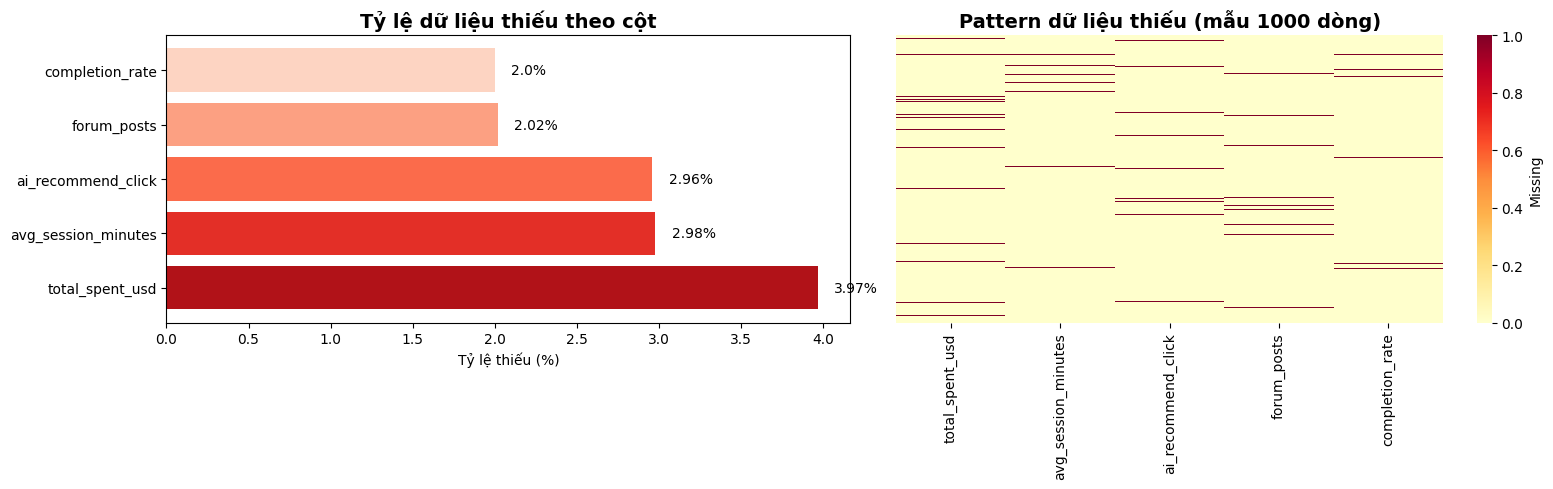

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
missing_cols = missing_df.index.tolist()
colors = sns.color_palette("Reds_r", len(missing_cols))
axes[0].barh(missing_cols, missing_df["Tỷ lệ (%)"], color=colors)
axes[0].set_xlabel("Tỷ lệ thiếu (%)")
axes[0].set_title("Tỷ lệ dữ liệu thiếu theo cột", fontsize=14, fontweight="bold")
for i, v in enumerate(missing_df["Tỷ lệ (%)"]):
    axes[0].text(v + 0.1, i, f"{v}%", va="center")

# Heatmap
sample = df[missing_cols].sample(1000, random_state=42)
sns.heatmap(sample.isnull(), cbar=True, yticklabels=False, ax=axes[1],
            cmap="YlOrRd", cbar_kws={"label": "Missing"})
axes[1].set_title("Pattern dữ liệu thiếu (mẫu 1000 dòng)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
print("TRƯỚC KHI XỬ LÝ:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

cols_fill_median = ["avg_session_minutes", "forum_posts", "completion_rate",
                    "total_spent_usd", "discount_used", "ai_recommend_click"]

for col in cols_fill_median:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col}: điền median = {median_val}")

print("SAU KHI XỬ LÝ:")
print(f"Tổng missing còn lại: {df.isnull().sum().sum()}")

TRƯỚC KHI XỬ LÝ:
avg_session_minutes    14912
forum_posts            10101
completion_rate        10018
total_spent_usd        19867
ai_recommend_click     14842
dtype: int64

  avg_session_minutes: điền median = 33.0
  forum_posts: điền median = 5.0
  completion_rate: điền median = 0.36
  total_spent_usd: điền median = 30.0
  discount_used: điền median = 4.0
  ai_recommend_click: điền median = 7.0
SAU KHI XỬ LÝ:
Tổng missing còn lại: 0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\283681702.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\283681702.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

# 2.1 . XỬ LÝ GIÁ TRỊ BẤT THƯỜNG

In [7]:
print("KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:")

print(f"age: min={df['age'].min()}, max={df['age'].max()}")
print(f"Giá trị ngoài [16, 40] : {((df['age'] < 16) | (df['age'] > 40)).sum()}")

print(f"completion_rate: min={df['completion_rate'].min()}, max={df['completion_rate'].max()}")
print(f"Giá trị ngoài [0, 1] : {((df['completion_rate'] < 0) | (df['completion_rate'] > 1)).sum()}")

print(f"sessions_per_week: min={df['sessions_per_week'].min()}, max={df['sessions_per_week'].max()}")
print(f"Giá trị âm : {(df['sessions_per_week'] < 0).sum()}")

print(f"total_spent_usd: min={df['total_spent_usd'].min()}, max={df['total_spent_usd'].max()}")
print(f"Giá trị âm : {(df['total_spent_usd'] < 0).sum()}")

for col in ["premium_purchased", "churn_risk", "future_purchase"]:
    print(f"{col}: unique : {sorted(df[col].unique())}")

KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:
age: min=17, max=35
Giá trị ngoài [16, 40] : 0
completion_rate: min=0.0, max=1.2
Giá trị ngoài [0, 1] : 15
sessions_per_week: min=0, max=17
Giá trị âm : 0
total_spent_usd: min=-10.0, max=350.0
Giá trị âm : 10
premium_purchased: unique : [np.int64(0), np.int64(1)]
churn_risk: unique : [np.int64(0), np.int64(1)]
future_purchase: unique : [np.int64(0), np.int64(1)]


In [8]:
print("XỬ LÝ GIÁ TRỊ BẤT THƯỜNG:")

df["age"] = df["age"].clip(lower=16, upper=45)
print("Đưa age về [16, 45]")

df["completion_rate"] = df["completion_rate"].clip(lower=0, upper=1)
print("Đưa completion_rate về [0, 1]")

df["sessions_per_week"] = df["sessions_per_week"].clip(lower=0)
print("Đảm bảo sessions_per_week >= 0")

df["total_spent_usd"] = df["total_spent_usd"].clip(lower=0)
print("Đảm bảo total_spent_usd >= 0")


XỬ LÝ GIÁ TRỊ BẤT THƯỜNG:
Đưa age về [16, 45]
Đưa completion_rate về [0, 1]
Đảm bảo sessions_per_week >= 0
Đảm bảo total_spent_usd >= 0


# 2.2 . Kiểm tra trùng lặp

In [9]:
dup_all = df.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {dup_all:,}")

dup_id = df.duplicated(subset=["user_id"]).sum()
print(f"Số dòng trùng user_id: {dup_id:,}")

if dup_id > 0:
    print(f"Có {dup_id:,} bản ghi trùng user_id.")
    df = df.drop_duplicates(subset=["user_id"], keep="first")
    print(f"Sau xử lý: {df.shape[0]:,} bản ghi")
else:
    print(" Không có dữ liệu trùng lặp.")

print(f"Kích thước dữ liệu sau làm sạch: {df.shape}")

Số dòng trùng lặp hoàn toàn: 1,000
Số dòng trùng user_id: 1,000
Có 1,000 bản ghi trùng user_id.
Sau xử lý: 500,000 bản ghi
Kích thước dữ liệu sau làm sạch: (500000, 20)


# 3. Phân tích bằng biểu đồ

#  Phân phối thời gian học gần như đồng đều, cho thấy sự đa dạng trong thói quen học.

# Median và Mean gần nhau → phân phối khá cân đối

# Người dùng Premium có xu hướng học lâu hơn so với Free users


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\2325267635.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="premium_purchased", y="avg_session_minutes", data=df, ax=axes[2],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\2325267635.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(["Free", "Premium"])


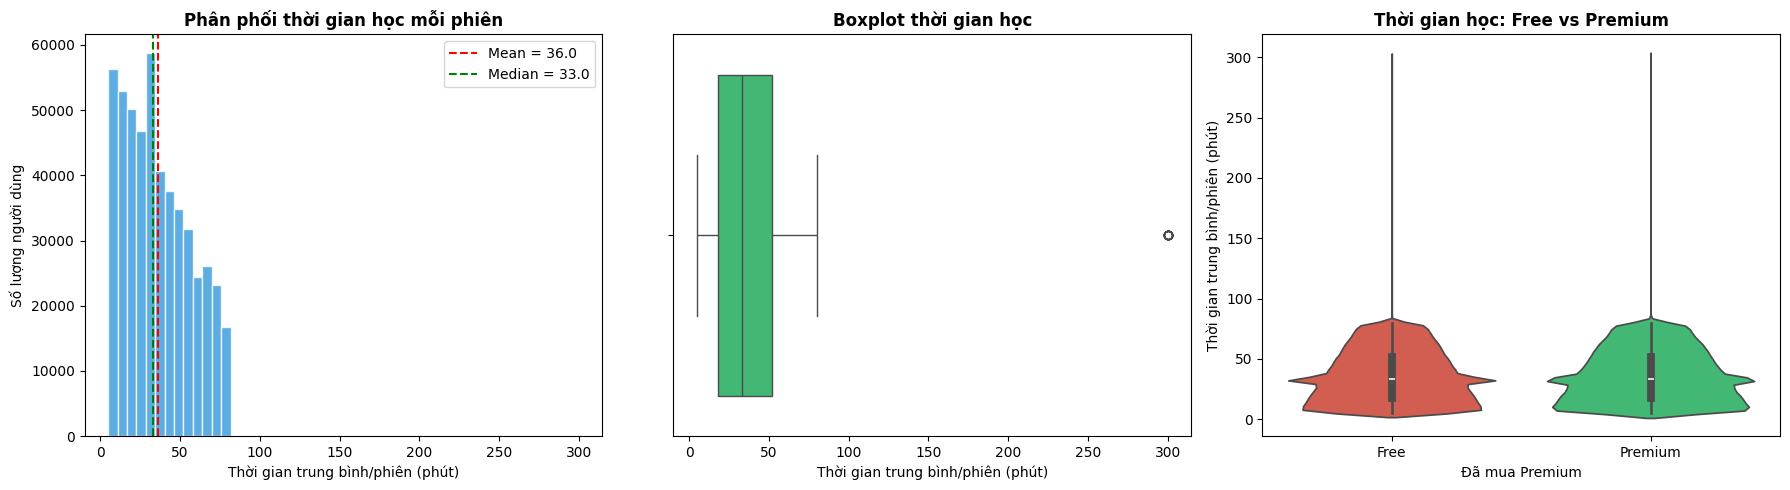

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df["avg_session_minutes"], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(df["avg_session_minutes"].mean(), color="red", linestyle="--", label=f'Mean = {df["avg_session_minutes"].mean():.1f}')
axes[0].axvline(df["avg_session_minutes"].median(), color="green", linestyle="--", label=f'Median = {df["avg_session_minutes"].median():.1f}')
axes[0].set_xlabel("Thời gian trung bình/phiên (phút)")
axes[0].set_ylabel("Số lượng người dùng")
axes[0].set_title("Phân phối thời gian học mỗi phiên", fontweight="bold")
axes[0].legend()

# Boxplot
sns.boxplot(x=df["avg_session_minutes"], ax=axes[1], color="#2ecc71")
axes[1].set_xlabel("Thời gian trung bình/phiên (phút)")
axes[1].set_title("Boxplot thời gian học", fontweight="bold")

# Violin theo Premium
sns.violinplot(x="premium_purchased", y="avg_session_minutes", data=df, ax=axes[2],
               palette=["#e74c3c", "#2ecc71"])
axes[2].set_xlabel("Đã mua Premium")
axes[2].set_ylabel("Thời gian trung bình/phiên (phút)")
axes[2].set_title("Thời gian học: Free vs Premium", fontweight="bold")
axes[2].set_xticklabels(["Free", "Premium"])

plt.tight_layout()
plt.show()

In [11]:
print(f"Thống kê avg_session_minutes:")
print(df["avg_session_minutes"].describe().round(2))

Thống kê avg_session_minutes:
count    500000.00
mean         36.03
std          20.74
min           5.00
25%          18.00
50%          33.00
75%          52.00
max         300.00
Name: avg_session_minutes, dtype: float64


#  3.1 Số lần truy cập mỗi tuần

# Đa số người dùng truy cập 1-5 lần/tuần

# Có một nhóm nhỏ power users truy cập >10 lần/tuần

# Không có sự khác biệt lớn giữa các quốc gia và ngành học"


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\608199907.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="country", y="sessions_per_week", data=df_top, ax=axes[1],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\608199907.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="sessions_per_week", data=df, ax=axes[2], palette="Set3")


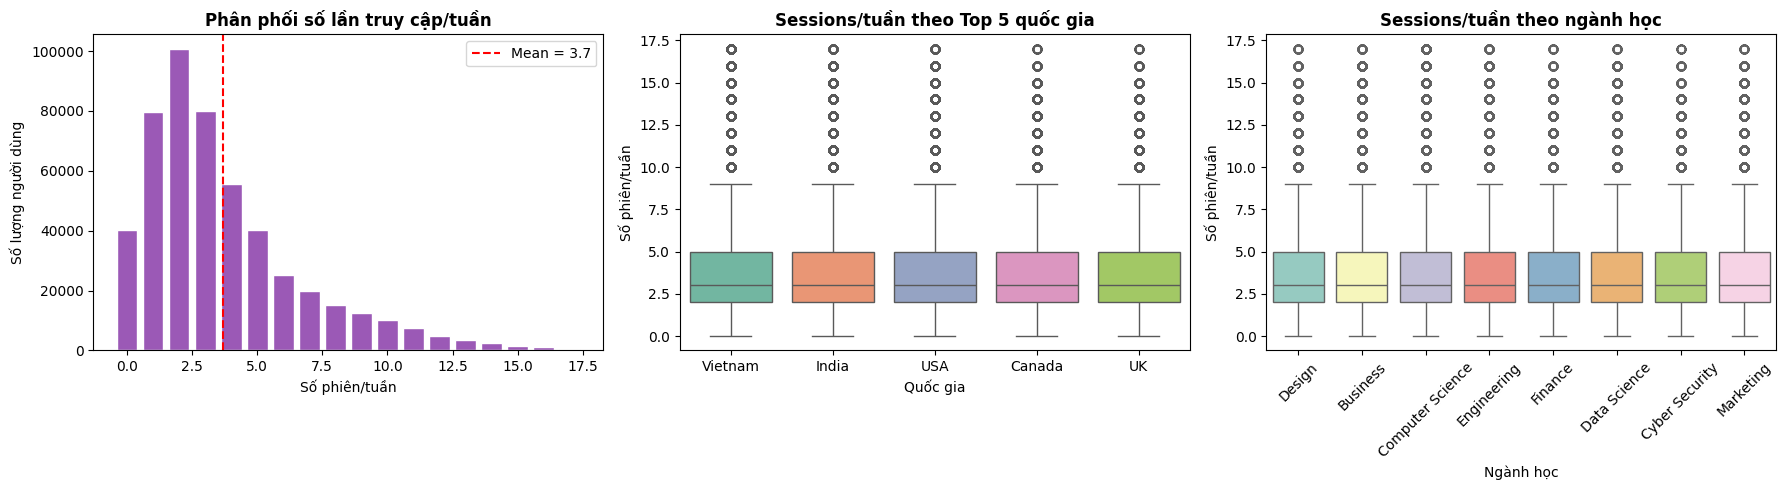

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
session_counts = df["sessions_per_week"].value_counts().sort_index()
axes[0].bar(session_counts.index, session_counts.values, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Số phiên/tuần")
axes[0].set_ylabel("Số lượng người dùng")
axes[0].set_title("Phân phối số lần truy cập/tuần", fontweight="bold")
axes[0].axvline(df["sessions_per_week"].mean(), color="red", linestyle="--",
                label=f'Mean = {df["sessions_per_week"].mean():.1f}')
axes[0].legend()

# Theo quốc gia (Top 5)
top_countries = df["country"].value_counts().head(5).index
df_top = df[df["country"].isin(top_countries)]
sns.boxplot(x="country", y="sessions_per_week", data=df_top, ax=axes[1],
            palette="Set2", order=top_countries)
axes[1].set_xlabel("Quốc gia")
axes[1].set_ylabel("Số phiên/tuần")
axes[1].set_title("Sessions/tuần theo Top 5 quốc gia", fontweight="bold")

# Theo ngành học
sns.boxplot(x="major", y="sessions_per_week", data=df, ax=axes[2], palette="Set3")
axes[2].set_xlabel("Ngành học")
axes[2].set_ylabel("Số phiên/tuần")
axes[2].set_title("Sessions/tuần theo ngành học", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 3.2. Mức độ hoàn thành khóa học (completion rate)

# Phân phối completion rate khá đồng đều, nhưng có nhiều người dùng ở mức thấp (<20%)

# Người có nguy cơ churn có completion rate rõ ràng thấp hơn

# Không có sự khác biệt lớn giữa các ngành học

# Chi tiêu không tỷ lệ thuận rõ ràng với completion rate"



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\3962403505.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\3962403505.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["Không rời bỏ", "Có nguy cơ"])


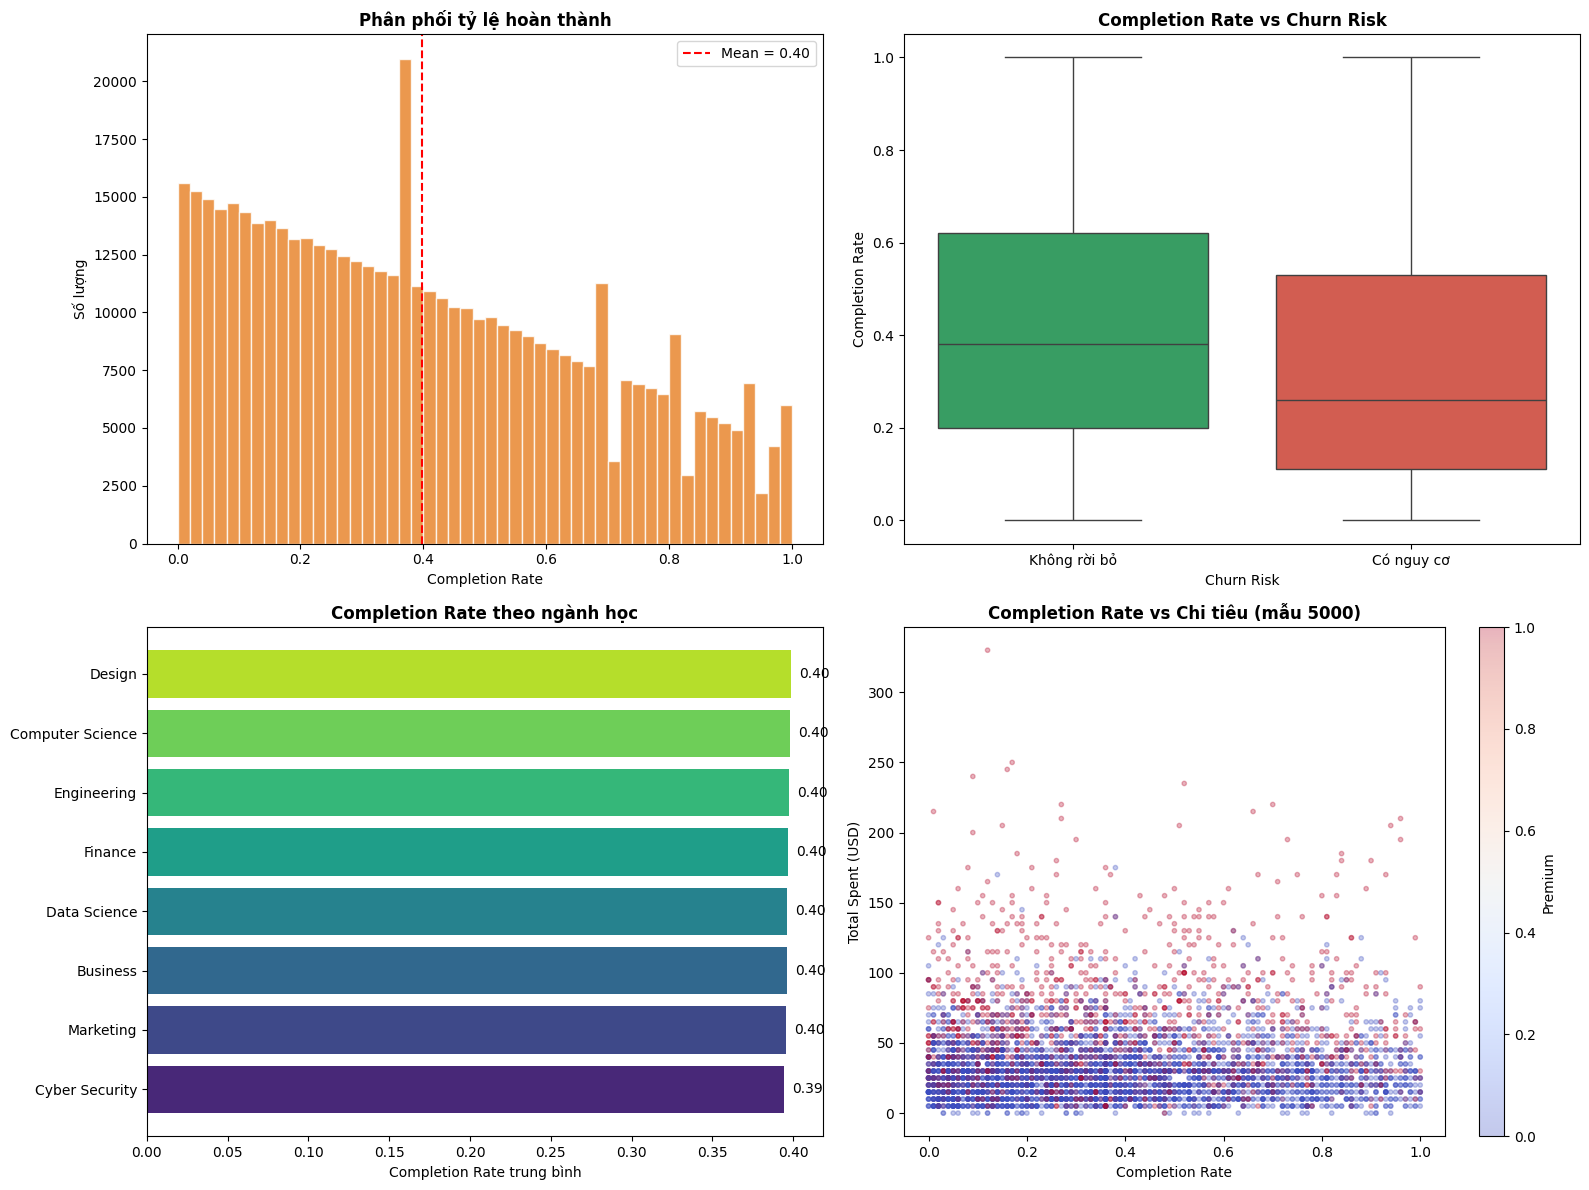

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(
    df["completion_rate"], bins=50, color="#e67e22", edgecolor="white", alpha=0.8
)
axes[0, 0].axvline(
    df["completion_rate"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["completion_rate"].mean():.2f}',
)
axes[0, 0].set_xlabel("Completion Rate")
axes[0, 0].set_ylabel("Số lượng")
axes[0, 0].set_title("Phân phối tỷ lệ hoàn thành", fontweight="bold")
axes[0, 0].legend()

# Completion rate theo churn_risk
sns.boxplot(
    x="churn_risk",
    y="completion_rate",
    data=df,
    ax=axes[0, 1],
    palette=["#27ae60", "#e74c3c"],
)
axes[0, 1].set_xlabel("Churn Risk")
axes[0, 1].set_ylabel("Completion Rate")
axes[0, 1].set_title("Completion Rate vs Churn Risk", fontweight="bold")
axes[0, 1].set_xticklabels(["Không rời bỏ", "Có nguy cơ"])

# Theo major
major_completion = (
    df.groupby("major")["completion_rate"].mean().sort_values(ascending=True)
)
axes[1, 0].barh(
    major_completion.index,
    major_completion.values,
    color=sns.color_palette("viridis", len(major_completion)),
)
axes[1, 0].set_xlabel("Completion Rate trung bình")
axes[1, 0].set_title("Completion Rate theo ngành học", fontweight="bold")
for i, v in enumerate(major_completion.values):
    axes[1, 0].text(v + 0.005, i, f"{v:.2f}", va="center")

# Scatter: completion_rate vs total_spent_usd
sample_plot = df.sample(5000, random_state=42)
scatter = axes[1, 1].scatter(
    sample_plot["completion_rate"],
    sample_plot["total_spent_usd"],
    c=sample_plot["premium_purchased"],
    cmap="coolwarm",
    alpha=0.3,
    s=10,
)
axes[1, 1].set_xlabel("Completion Rate")
axes[1, 1].set_ylabel("Total Spent (USD)")
axes[1, 1].set_title("Completion Rate vs Chi tiêu (mẫu 5000)", fontweight="bold")
plt.colorbar(scatter, ax=axes[1, 1], label="Premium")

plt.tight_layout()
plt.show()

In [14]:
bins = [0, 0.2, 0.5, 0.8, 1.0]
labels = ["Rất thấp (<20%)", "Thấp (20-50%)", "Trung bình (50-80%)", "Cao (>80%)"]
df["completion_group"] = pd.cut(df["completion_rate"], bins=bins, labels=labels, include_lowest=True)
print("Phân bố nhóm completion rate:")
print(df["completion_group"].value_counts().sort_index())

Phân bố nhóm completion rate:
completion_group
Rất thấp (<20%)        150675
Thấp (20-50%)          181133
Trung bình (50-80%)    118514
Cao (>80%)              49678
Name: count, dtype: int64


# 3.3 Xu hướng học theo thời gian"

# Người dùng mới (0-30 ngày) có sessions/tuần và completion rate ổn định

# Không có sự suy giảm rõ rệt theo thời gian → retention tương đối ổn

# Tỷ lệ churn có thể tăng nhẹ ở các cohort cũ hơn

# Videos watched khá đồng đều giữa các cohort"



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\1365736140.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_sessions = df.groupby("signup_period")["sessions_per_week"].mean()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\1365736140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_completion = df.groupby("signup_period")["completion_rate"].mean()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\1365736140.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

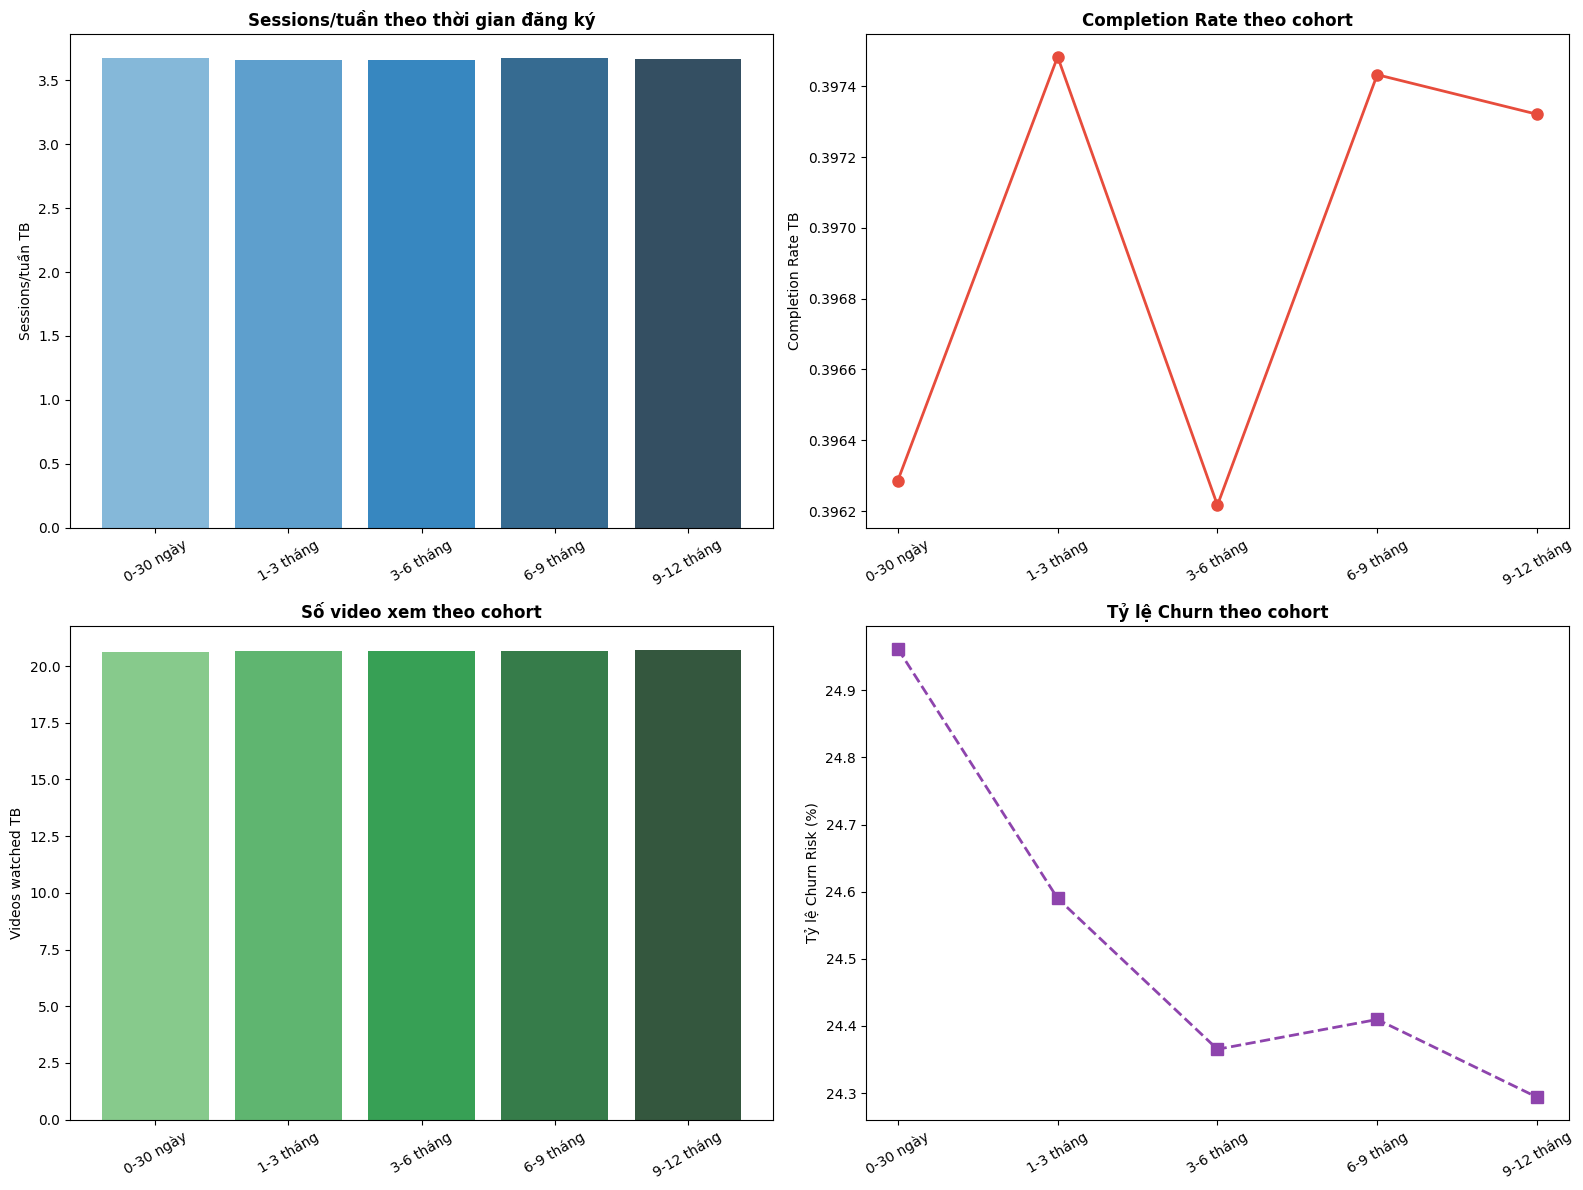

In [15]:
ig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Phân nhóm theo thời gian đăng ký
df["signup_period"] = pd.cut(df["signup_days_ago"],
                              bins=[0, 30, 90, 180, 270, 365],
                              labels=["0-30 ngày", "1-3 tháng", "3-6 tháng", "6-9 tháng", "9-12 tháng"])

# Số phiên/tuần theo cohort
cohort_sessions = df.groupby("signup_period")["sessions_per_week"].mean()
axes[0, 0].bar(range(len(cohort_sessions)), cohort_sessions.values, color=sns.color_palette("Blues_d", len(cohort_sessions)))
axes[0, 0].set_xticks(range(len(cohort_sessions)))
axes[0, 0].set_xticklabels(cohort_sessions.index, rotation=30)
axes[0, 0].set_ylabel("Sessions/tuần TB")
axes[0, 0].set_title("Sessions/tuần theo thời gian đăng ký", fontweight="bold")

# Completion rate theo cohort
cohort_completion = df.groupby("signup_period")["completion_rate"].mean()
axes[0, 1].plot(range(len(cohort_completion)), cohort_completion.values, "o-", color="#e74c3c", linewidth=2, markersize=8)
axes[0, 1].set_xticks(range(len(cohort_completion)))
axes[0, 1].set_xticklabels(cohort_completion.index, rotation=30)
axes[0, 1].set_ylabel("Completion Rate TB")
axes[0, 1].set_title("Completion Rate theo cohort", fontweight="bold")

# Videos watched theo cohort
cohort_videos = df.groupby("signup_period")["videos_watched"].mean()
axes[1, 0].bar(range(len(cohort_videos)), cohort_videos.values, color=sns.color_palette("Greens_d", len(cohort_videos)))
axes[1, 0].set_xticks(range(len(cohort_videos)))
axes[1, 0].set_xticklabels(cohort_videos.index, rotation=30)
axes[1, 0].set_ylabel("Videos watched TB")
axes[1, 0].set_title("Số video xem theo cohort", fontweight="bold")

# Tỷ lệ churn theo cohort
cohort_churn = df.groupby("signup_period")["churn_risk"].mean() * 100
axes[1, 1].plot(range(len(cohort_churn)), cohort_churn.values, "s--", color="#8e44ad", linewidth=2, markersize=8)
axes[1, 1].set_xticks(range(len(cohort_churn)))
axes[1, 1].set_xticklabels(cohort_churn.index, rotation=30)
axes[1, 1].set_ylabel("Tỷ lệ Churn Risk (%)")
axes[1, 1].set_title("Tỷ lệ Churn theo cohort", fontweight="bold")

plt.tight_layout()
plt.show()

# 4. PHÁT HIỆN OUTLIERS

In [16]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# Outliers về sessions_per_week
out_sessions, low_s, up_s = detect_outliers_iqr(df, "sessions_per_week")
print(f"Sessions/tuần - Ngưỡng: [{low_s:.1f}, {up_s:.1f}]")
print(f"Số outliers: {len(out_sessions):,} ({len(out_sessions)/len(df)*100:.2f}%)")

# Outliers về avg_session_minutes  
out_minutes, low_m, up_m = detect_outliers_iqr(df, "avg_session_minutes")
print(f"Avg session minutes - Ngưỡng: [{low_m:.1f}, {up_m:.1f}]")
print(f"Số outliers: {len(out_minutes):,} ({len(out_minutes)/len(df)*100:.2f}%)")

# Outliers về videos_watched
out_videos, low_v, up_v = detect_outliers_iqr(df, "videos_watched")
print(f"Videos watched - Ngưỡng: [{low_v:.1f}, {up_v:.1f}]")
print(f"Số outliers: {len(out_videos):,} ({len(out_videos)/len(df)*100:.2f}%)")

# Người học "siêu tích cực": sessions >= 10 VÀ avg_minutes >= 60
super_active = df[(df["sessions_per_week"] >= 10) & (df["avg_session_minutes"] >= 60)]
print(f"Người dùng siêu tích cực (sessions>=10, minutes>=60): {len(super_active):,}")
print(super_active[["user_id", "sessions_per_week", "avg_session_minutes", "videos_watched",
                    "completion_rate", "premium_purchased"]].head(10))

Sessions/tuần - Ngưỡng: [-2.5, 9.5]
Số outliers: 31,361 (6.27%)
Avg session minutes - Ngưỡng: [-33.0, 103.0]
Số outliers: 15 (0.00%)
Videos watched - Ngưỡng: [-28.0, 68.0]
Số outliers: 0 (0.00%)
Người dùng siêu tích cực (sessions>=10, minutes>=60): 5,310
      user_id  sessions_per_week  avg_session_minutes  videos_watched  \
82         83                 12                 75.0              13   
110       111                 15                 62.0              20   
349       350                 11                 68.0              34   
457       458                 15                 69.0              26   
495       496                 13                 80.0               5   
565       566                 11                 78.0               5   
1030     1031                 13                 70.0              50   
1083     1084                 11                 76.0               5   
1197     1198                 11                 67.0              28   
1260     1261  

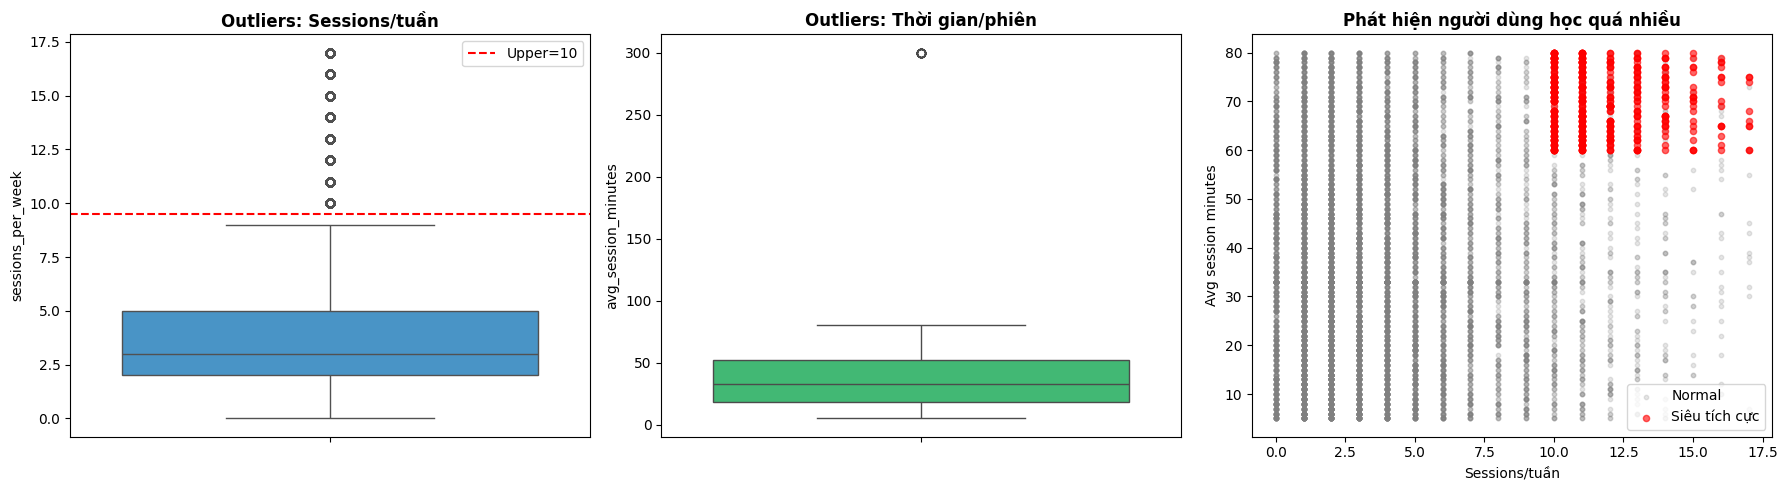

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot sessions
sns.boxplot(y=df["sessions_per_week"], ax=axes[0], color="#3498db")
axes[0].set_title("Outliers: Sessions/tuần", fontweight="bold")
axes[0].axhline(up_s, color="red", linestyle="--", label=f"Upper={up_s:.0f}")
axes[0].legend()

# Boxplot avg_session_minutes
sns.boxplot(y=df["avg_session_minutes"], ax=axes[1], color="#2ecc71")
axes[1].set_title("Outliers: Thời gian/phiên", fontweight="bold")

# Scatter: sessions vs minutes (highlight outliers)
sample_df = df.sample(10000, random_state=42)
axes[2].scatter(sample_df["sessions_per_week"], sample_df["avg_session_minutes"],
                alpha=0.2, s=10, color="gray", label="Normal")
super_sample = super_active.sample(min(500, len(super_active)), random_state=42)
axes[2].scatter(super_sample["sessions_per_week"], super_sample["avg_session_minutes"],
                alpha=0.6, s=20, color="red", label="Siêu tích cực")
axes[2].set_xlabel("Sessions/tuần")
axes[2].set_ylabel("Avg session minutes")
axes[2].set_title("Phát hiện người dùng học quá nhiều", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

# 4.1. Người dùng đăng ký nhiều khóa nhưng không học

In [18]:
ghost_users = df[(df["courses_enrolled"] >= 10) & (df["completion_rate"] <= 0.1)]
print(f"Người dùng đăng ký nhiều khóa nhưng không học (đăng ký ≥10 khóa, hoàn thành ≤10%): {len(ghost_users):,}")
print(f"Tỷ lệ: {len(ghost_users)/len(df)*100:.2f}%")
print()

Người dùng đăng ký nhiều khóa nhưng không học (đăng ký ≥10 khóa, hoàn thành ≤10%): 27,972
Tỷ lệ: 5.59%



In [19]:
print("Thống kê nhóm Ghost Users:")
print(ghost_users[["sessions_per_week", "avg_session_minutes", "videos_watched",
                    "courses_enrolled", "completion_rate", "total_spent_usd",
                    "premium_purchased", "churn_risk"]].describe().round(2))

Thống kê nhóm Ghost Users:
       sessions_per_week  avg_session_minutes  videos_watched  \
count           27972.00             27972.00        27972.00   
mean                3.66                35.88           20.56   
std                 3.06                20.61           14.05   
min                 0.00                 5.00            0.00   
25%                 2.00                18.00            8.00   
50%                 3.00                33.00           19.00   
75%                 5.00                52.00           32.00   
max                17.00               300.00           50.00   

       courses_enrolled  completion_rate  total_spent_usd  premium_purchased  \
count          27972.00         27972.00         27972.00           27972.00   
mean              13.05             0.05            38.02               0.28   
std                2.24             0.03            30.99               0.45   
min               10.00             0.00             0.00          

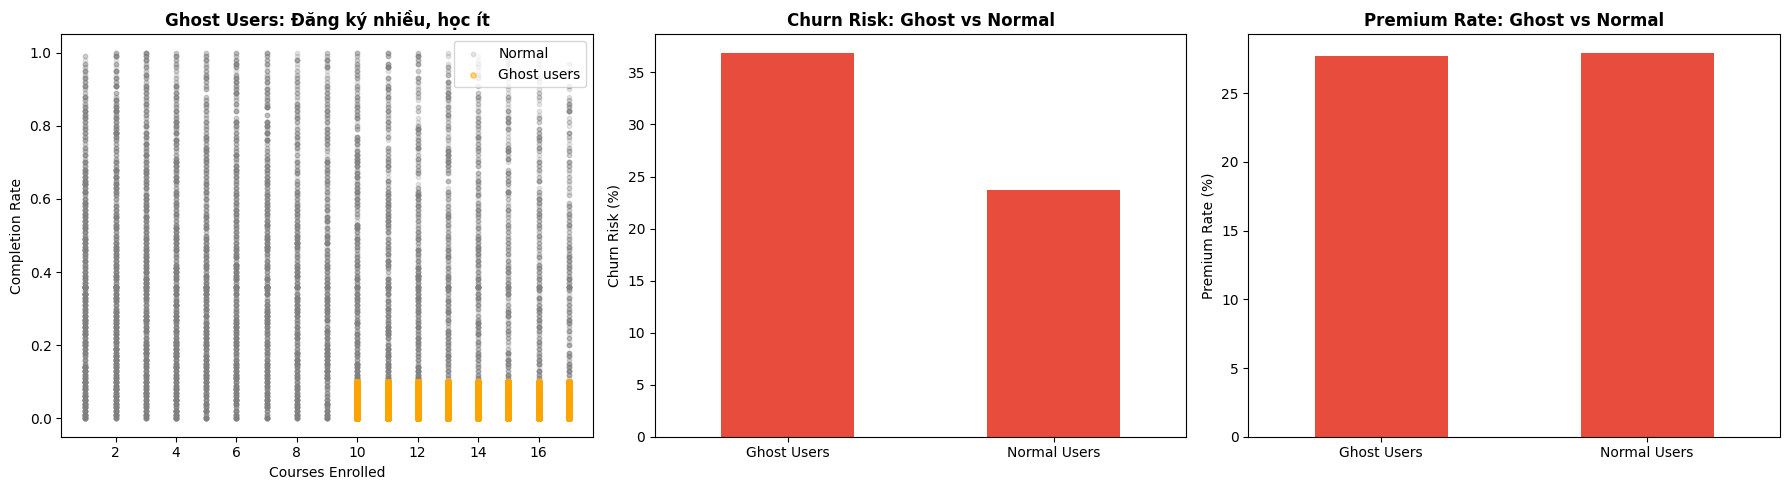

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# courses_enrolled vs completion_rate
sample_all = df.sample(10000, random_state=42)
axes[0].scatter(sample_all["courses_enrolled"], sample_all["completion_rate"],
                alpha=0.2, s=10, color="gray", label="Normal")
ghost_sample = ghost_users.sample(min(2000, len(ghost_users)), random_state=42)
axes[0].scatter(ghost_sample["courses_enrolled"], ghost_sample["completion_rate"],
                alpha=0.5, s=15, color="orange", label="Ghost users")
axes[0].set_xlabel("Courses Enrolled")
axes[0].set_ylabel("Completion Rate")
axes[0].set_title("Ghost Users: Đăng ký nhiều, học ít", fontweight="bold")
axes[0].legend()

# So sánh churn risk
groups = pd.DataFrame({
    "Ghost Users": [ghost_users["churn_risk"].mean() * 100],
    "Normal Users": [df[~df.index.isin(ghost_users.index)]["churn_risk"].mean() * 100]
}).T
groups.columns = ["Churn Risk (%)"]
groups.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2ecc71"], legend=False)
axes[1].set_title("Churn Risk: Ghost vs Normal", fontweight="bold")
axes[1].set_ylabel("Churn Risk (%)")
axes[1].tick_params(axis="x", rotation=0)

# Premium rate
premium = pd.DataFrame({
    "Ghost Users": [ghost_users["premium_purchased"].mean() * 100],
    "Normal Users": [df[~df.index.isin(ghost_users.index)]["premium_purchased"].mean() * 100]
}).T
premium.columns = ["Premium Rate (%)"]
premium.plot(kind="bar", ax=axes[2], color=["#e74c3c", "#3498db"], legend=False)
axes[2].set_title("Premium Rate: Ghost vs Normal", fontweight="bold")
axes[2].set_ylabel("Premium Rate (%)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Nhận xét

# Nhóm Ghost Users đăng ký nhiều khóa (≥10) nhưng completion rate rất thấp (≤10%)

# Nhóm này có nguy cơ churn cao hơn đáng kể so với nhóm bình thường



# 4.2 . Người dùng chi tiêu bất thường

In [21]:
out_spent, low_sp, up_sp = detect_outliers_iqr(df, "total_spent_usd")
print(f"Total Spent USD - Ngưỡng IQR: [{low_sp:.1f}, {up_sp:.1f}]")
print(f"Số outliers chi tiêu: {len(out_spent):,} ({len(out_spent)/len(df)*100:.2f}%)")

# Người chi tiêu cao nhất
high_spenders = df[df["total_spent_usd"] >= 150].sort_values("total_spent_usd", ascending=False)
print(f"Người dùng chi tiêu ≥150 USD: {len(high_spenders):,}")
print(high_spenders[["user_id", "total_spent_usd", "courses_enrolled", "completion_rate",
                      "premium_purchased", "sessions_per_week"]].head(15))

# Người chi 0 USD nhưng premium
zero_spend_premium = df[(df["total_spent_usd"] == 0) & (df["premium_purchased"] == 1)]
print(f"Premium nhưng chi tiêu = 0 USD: {len(zero_spend_premium):,}")

Total Spent USD - Ngưỡng IQR: [-37.5, 102.5]
Số outliers chi tiêu: 22,410 (4.48%)
Người dùng chi tiêu ≥150 USD: 6,083
        user_id  total_spent_usd  courses_enrolled  completion_rate  \
420635   420636            350.0                 4             0.45   
402785   402786            350.0                 2             0.30   
27772     27773            350.0                 2             0.12   
152752   152753            350.0                 8             0.26   
367720   367721            350.0                 1             0.04   
483888   483889            350.0                 9             0.58   
240520   240521            350.0                 9             0.90   
468932   468933            350.0                14             0.52   
113396   113397            350.0                14             0.28   
297862   297863            350.0                11             0.11   
312280   312281            350.0                11             0.70   
20741     20742            350

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\2620507292.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="premium_purchased", y="total_spent_usd", data=df, ax=axes[1],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\2620507292.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Free", "Premium"])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15736\2620507292.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


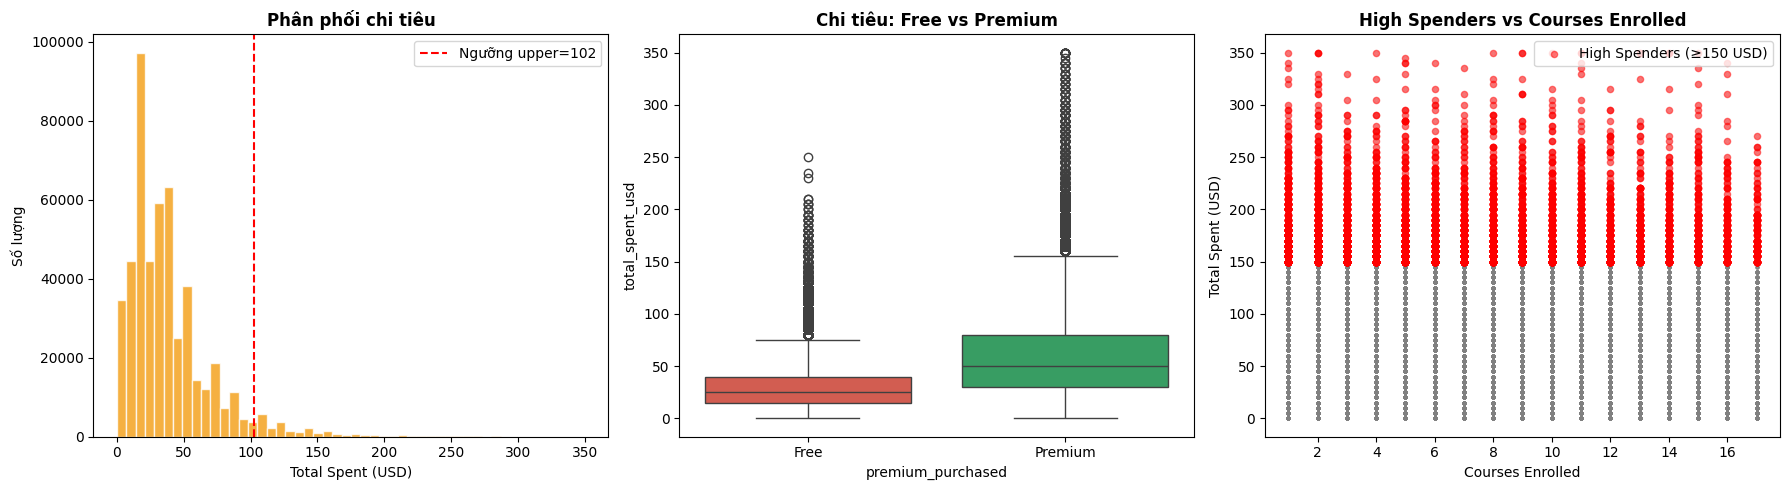

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram chi tiêu
axes[0].hist(df["total_spent_usd"], bins=50, color="#f39c12", edgecolor="white", alpha=0.8)
axes[0].axvline(up_sp, color="red", linestyle="--", label=f"Ngưỡng upper={up_sp:.0f}")
axes[0].set_xlabel("Total Spent (USD)")
axes[0].set_ylabel("Số lượng")
axes[0].set_title("Phân phối chi tiêu", fontweight="bold")
axes[0].legend()

# Boxplot chi tiêu theo premium
sns.boxplot(x="premium_purchased", y="total_spent_usd", data=df, ax=axes[1],
            palette=["#e74c3c", "#27ae60"])
axes[1].set_xticklabels(["Free", "Premium"])
axes[1].set_title("Chi tiêu: Free vs Premium", fontweight="bold")

# Top spenders - scatter
axes[2].scatter(df["courses_enrolled"], df["total_spent_usd"], alpha=0.1, s=5, color="gray")
axes[2].scatter(high_spenders["courses_enrolled"], high_spenders["total_spent_usd"],
                alpha=0.5, s=20, color="red", label="High Spenders (≥150 USD)")
axes[2].set_xlabel("Courses Enrolled")
axes[2].set_ylabel("Total Spent (USD)")
axes[2].set_title("High Spenders vs Courses Enrolled", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()